### 3.6.1. Integer Programming (IP)

$$
\begin{aligned}
\max_{\mathbf{x}}\quad & \mathbf{c}^\top \mathbf{x} \\
\text{subject to}\quad & A\mathbf{x} \le \mathbf{b},\\
& \mathbf{x} \ge \mathbf 0,\quad \mathbf{x}\in\mathbb{Z}^n.
\end{aligned}
$$

**Explanation:**

An integer program (IP) is a linear program with the added requirement that the decision variables take integer values. This requirement destroys convexity of the feasible set — it becomes a lattice of isolated points — so the [simplex](../04_Convex_Problem_Classes/01_linear_programming.ipynb) optimum of the continuous *LP relaxation* is generally not integer. The relaxation still provides a bound: for a maximization it is an upper bound on the integer optimum, and rounding it may give an infeasible or suboptimal point, which is why exact methods rely on [branch and bound](../08_Global_and_Derivative_Free_Optimization/02_branch_and_bound.ipynb).

**Intuition:**

Only the grid points inside the shaded polyhedron are admissible; the LP optimum sits at a fractional corner that no rounding necessarily reaches.

![Integer feasible lattice inside the LP polyhedron](../../Figures/030601_integer_program_feasible_lattice.png)

**Numerical Example:**

$$
\max\; 5x_1 + 4x_2
\quad\text{s.t.}\quad
6x_1 + 4x_2 \le 24,\;\; x_1 + 2x_2 \le 6,\;\; x_1,x_2 \in \mathbb{Z}_{\ge 0}.
$$

The LP relaxation optimum is the fractional corner $(x_1,x_2) = (3, 1.5)$ with value $21$. Rounding to $(3,2)$ violates $x_1+2x_2\le 6$, so it is infeasible. Enumerating the integer lattice points that satisfy both constraints, the best is
$$
\mathbf{x}^\star = (4, 0),\qquad 5(4) + 4(0) = 20,
$$
strictly below the relaxation bound of $21$.

In [1]:
import sympy as sp

objective_coefficients = sp.Matrix([5, 4])

def satisfies_constraints(x_1, x_2):
    return 6*x_1 + 4*x_2 <= 24 and x_1 + 2*x_2 <= 6

feasible_points = [(x_1, x_2)
                   for x_1 in range(0, 5)
                   for x_2 in range(0, 4)
                   if satisfies_constraints(x_1, x_2)]
best_point = max(feasible_points, key=lambda point: 5*point[0] + 4*point[1])
best_value = 5*best_point[0] + 4*best_point[1]

print("feasible integer points:", feasible_points)
print("integer optimum:", best_point, "value:", best_value)
print("LP relaxation optimum: (3, 1.5) value 21")

feasible integer points: [(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (2, 0), (2, 1), (2, 2), (3, 0), (3, 1), (4, 0)]
integer optimum: (4, 0) value: 20
LP relaxation optimum: (3, 1.5) value 21


**Equivalent scipy.milp implementation:**

In [2]:
import numpy as np
from scipy.optimize import milp, LinearConstraint, Bounds

cost = np.array([-5.0, -4.0])
constraint_matrix = np.array([[6.0, 4.0], [1.0, 2.0]])
constraints = LinearConstraint(constraint_matrix, -np.inf, [24, 6])
result = milp(c=cost, constraints=constraints, integrality=np.ones(2),
              bounds=Bounds(lb=0, ub=np.inf))

print("integer optimum:", result.x, "value:", -result.fun)

integer optimum: [ 4. -0.] value: 20.0


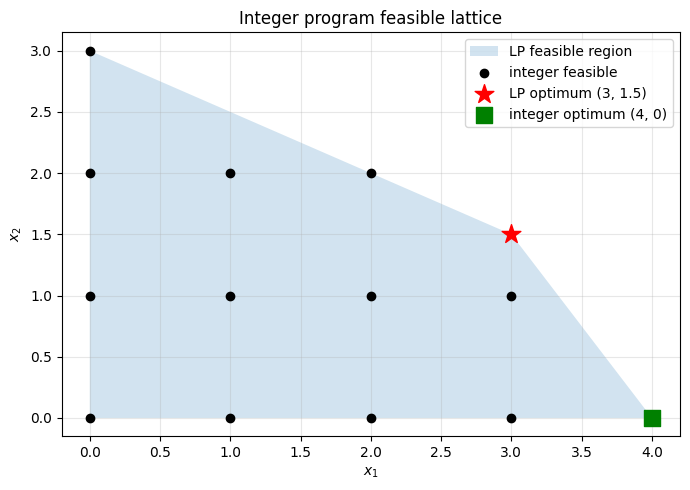

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_1_grid = np.linspace(0, 4.5, 200)
plt.figure(figsize=(7, 5))
plt.fill_between(x_1_grid, 0, np.minimum((24 - 6*x_1_grid)/4, (6 - x_1_grid)/2),
                 where=np.minimum((24 - 6*x_1_grid)/4, (6 - x_1_grid)/2) >= 0,
                 alpha=0.2, label="LP feasible region")
lattice = [(x_1, x_2) for x_1 in range(0, 5) for x_2 in range(0, 4)
           if 6*x_1 + 4*x_2 <= 24 and x_1 + 2*x_2 <= 6]
plt.scatter([p[0] for p in lattice], [p[1] for p in lattice], color="black", zorder=3, label="integer feasible")
plt.scatter([3], [1.5], color="red", marker="*", s=200, zorder=4, label="LP optimum (3, 1.5)")
plt.scatter([4], [0], color="green", marker="s", s=120, zorder=4, label="integer optimum (4, 0)")
plt.xlabel("$x_1$"); plt.ylabel("$x_2$"); plt.title("Integer program feasible lattice")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

**References:**

[📘 Wolsey, L. A. (1998). *Integer Programming*. Wiley.](https://www.wiley.com/en-us/Integer+Programming-p-9781119606536)  
[📗 Postek, K., & Zocca, A. (2024). *Hands-On Mathematical Optimization with Python*, Ch. 3–4. Cambridge University Press.](https://mobook.github.io/MO-book/intro.html)

---

[⬅️ Previous: Penalty and Barrier Methods](../05_Nonlinear_Programming/13_penalty_and_barrier_methods.ipynb) | [Next: Binary Integer Programming (BIP) ➡️](./02_binary_integer_programming.ipynb)